# Simulating Multiple-Orbital Systems

This notebook shows a compact `k=2` setup where each hopping can be a `2x2` block.


## 1. Setup

We define the lattice once with `k=2` and reuse it in all later cells.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from moirepy import BilayerMoireLattice, TriangularLayer

lattice = BilayerMoireLattice(
    latticetype=TriangularLayer,
    ll1=2,
    ll2=3,
    ul1=3,
    ul2=2,
    n1=1,
    n2=1,
    k=2,
    pbc=True,
)

lattice.generate_connections(inter_layer_radius=1.0)


twist angle = 0.2299 rad (13.1736 deg)
19 cells in upper lattice
19 cells in lower lattice


## 2. Build a Block Hamiltonian

Here we mix scalar and matrix-valued inputs:
- In general the t's should be functions that take in certain parameters (as shown in [custom_hoppings file](custom_hoppings.ipynb)) and returns `k x k` blocks, where `k` is the number of orbitals per site. But here are some relaxations to the rule.
- If the hopping is supposed to remain constant across the lattice, you can directly input the `k x k` block without wrapping it in a function.
- If the hopping between any two orbitals is the same, you can directly input a scalar. The code will automatically broadcast it to a full `k x k` block.
- If the hopping between any two orbitals is the same, but it is different across the lattice, you can input a function that returns a scalar. The code will automatically broadcast it to a full `k x k` block.

In [2]:
real_ham = lattice.generate_hamiltonian(
    tll=0.3,
    tuu=0.0,
    tul=(
        (0.8, 0.5),
        (0.5, 0.8),
    ),
    tlu=1.0,
    tuself=0.2,
    tlself=(
        (0.4, 0.1),
        (0.1, 0.4),
    ),
    data_type=np.float64,  # default is np.complex128
).toarray()  # convert to dense array for visualization purposes

print("Hamiltonian shape:", real_ham.shape)

Hamiltonian shape: (76, 76)


## 3. Visualize Matrix Structure

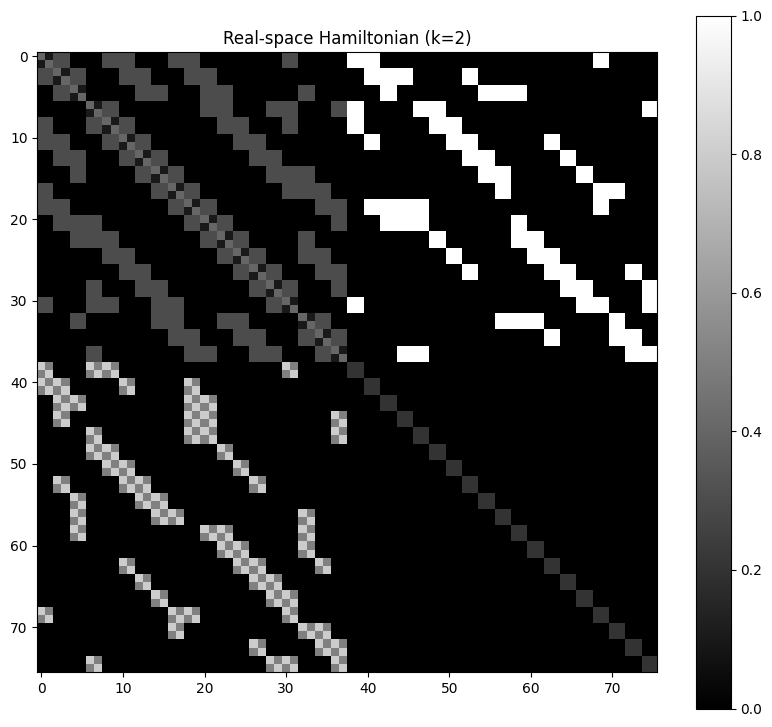

In [3]:
plt.figure(figsize=(10, 9))
plt.imshow(real_ham, cmap='gray')
plt.title('Real-space Hamiltonian (k=2)')
plt.colorbar()

## 4. Inspect a Small Block

In [ ]:
print(real_ham[:16, :16])

[[0.4 0.1 0.3 0.3 0.  0.  0.  0.  0.3 0.3 0.3 0.3 0.  0.  0.  0. ]
 [0.1 0.4 0.3 0.3 0.  0.  0.  0.  0.3 0.3 0.3 0.3 0.  0.  0.  0. ]
 [0.3 0.3 0.4 0.1 0.3 0.3 0.  0.  0.  0.  0.3 0.3 0.3 0.3 0.  0. ]
 [0.3 0.3 0.1 0.4 0.3 0.3 0.  0.  0.  0.  0.3 0.3 0.3 0.3 0.  0. ]
 [0.  0.  0.3 0.3 0.4 0.1 0.  0.  0.  0.  0.  0.  0.3 0.3 0.3 0.3]
 [0.  0.  0.3 0.3 0.1 0.4 0.  0.  0.  0.  0.  0.  0.3 0.3 0.3 0.3]
 [0.  0.  0.  0.  0.  0.  0.4 0.1 0.3 0.3 0.  0.  0.  0.  0.  0. ]
 [0.  0.  0.  0.  0.  0.  0.1 0.4 0.3 0.3 0.  0.  0.  0.  0.  0. ]
 [0.3 0.3 0.  0.  0.  0.  0.3 0.3 0.4 0.1 0.3 0.3 0.  0.  0.  0. ]
 [0.3 0.3 0.  0.  0.  0.  0.3 0.3 0.1 0.4 0.3 0.3 0.  0.  0.  0. ]
 [0.3 0.3 0.3 0.3 0.  0.  0.  0.  0.3 0.3 0.4 0.1 0.3 0.3 0.  0. ]
 [0.3 0.3 0.3 0.3 0.  0.  0.  0.  0.3 0.3 0.1 0.4 0.3 0.3 0.  0. ]
 [0.  0.  0.3 0.3 0.3 0.3 0.  0.  0.  0.  0.3 0.3 0.4 0.1 0.3 0.3]
 [0.  0.  0.3 0.3 0.3 0.3 0.  0.  0.  0.  0.3 0.3 0.1 0.4 0.3 0.3]
 [0.  0.  0.  0.  0.3 0.3 0.  0.  0.  0.  0.  0.  0.3 0.3 0.4 

## Summary

- Setting `k=2` promotes each site to a `2x2` orbital block.
- You can combine scalar terms with explicit `(k, k)` matrices.
- The generated Hamiltonian remains a standard sparse matrix, ready for downstream analysis.
